# Merton–Altman Energy Credit Risk Engine
### Structural and Accounting-Based Credit Risk Assessment of Major Indian Oil & Gas Companies

**Research question**: How resilient are major Indian oil and gas companies to financial and market shocks, and what do structural and accounting-based credit models indicate about their credit risk?

This notebook is the executable core of the project. It is organised in 38 cells covering: industry context, finance fundamentals, data collection, cleaning, the financial ratio engine, the Altman Z''-Score, the Merton structural model and its numerical solver, model comparison, peer ranking, a custom credit score, five-year trends, an early-warning system, energy-sector stress testing (profitability/debt/equity/oil-price/business-model/combined bear case/reverse stress), sensitivity analysis, a brief note on why ML is deliberately excluded, visualisations, the dashboard, a Reliance comparability discussion, an IOC deep dive, final results, exports, and a final project audit.

**Disclaimer**: educational/portfolio project, not investment advice or a credit rating. See `docs/limitations.md`.

## Why Oil & Gas Credit Risk?

Oil & gas companies combine (1) capital intensity and meaningful leverage, (2) large, long-lived fixed-asset bases, (3) working-capital swings tied to inventory/receivables, (4) direct commodity-price exposure, and (5) - in India specifically - significant government ownership and, for downstream players, historic exposure to regulated fuel-pricing "under-recoveries". Upstream (ONGC, Oil India) is long crude/gas prices; downstream (IOC, BPCL, HPCL) is exposed to refining *margins* and working capital, not the absolute oil price; gas transmission (GAIL) is more regulated-utility-like, exposed mainly to volumes; Reliance is a diversified conglomerate where oil & gas (O2C) is only part of the credit story. This project treats these as **distinct business models with differentiated stress assumptions**, not one undifferentiated "oil & gas" bucket.

## Finance Concepts (just enough to follow the rest of this notebook)

- **Credit risk**: the risk that a borrower cannot meet its debt obligations in full and on time.
- **Leverage**: Debt relative to earnings (Debt/EBITDA) or equity (Debt/Equity) - more leverage means less cushion before debt obligations become hard to meet.
- **Equity as a call option (Merton's insight)**: shareholders get paid only after debt is serviced; if firm assets are worth less than the debt owed, equity is - under this simplified model - worth zero, and equity holders will not "exercise" (i.e., will not top up the shortfall) because of limited liability. This makes equity mathematically equivalent to a call option on firm assets, struck at the face value of debt.
- **Distance-to-Default (DD)**: how many standard deviations of asset-value movement separate the current estimated asset value from the debt threshold. Higher DD = more cushion = lower model-implied risk.
- **Altman Z-Score**: a weighted combination of accounting ratios (liquidity, cumulative profitability, operating profitability, leverage) that historically discriminated well between distressed and non-distressed firms.
- **Risk-neutral vs physical probability**: the Merton model, being built on option-pricing theory, naturally produces a *risk-neutral* default probability (assumes assets drift at the risk-free rate) - not the same as a real-world ("physical") probability, which is systematically lower. See Cell 18.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

print('Environment ready.')

Environment ready.


In [2]:
FISCAL_YEARS = [2021, 2022, 2023, 2024, 2025]
CURRENT_SNAPSHOT_DATE = '2026-08-14'
CURRENT_RISK_FREE_RATE = 0.0676   # TradingEconomics, 14-Aug-2026, cross-checked vs FRED
ERP_INDIA = 0.07                  # India total equity risk premium (Damodaran-style est., ~Jan-2026 vintage)
TIME_HORIZON_YEARS = 1.0

print(f"Analysis period: FY{FISCAL_YEARS[0]}-FY{FISCAL_YEARS[-1]}")
print(f"Market snapshot date: {CURRENT_SNAPSHOT_DATE}")
print(f"Current risk-free rate: {CURRENT_RISK_FREE_RATE:.2%}")

Analysis period: FY2021-FY2025
Market snapshot date: 2026-08-14
Current risk-free rate: 6.76%


In [3]:
from data_collection import load_company_universe
universe = load_company_universe()
universe

,company,name,nse_symbol,screener_code,business_model,ownership,peer_group
0,ONGC,Oil and Natural Gas Corporation Ltd.,ONGC,ONGC,Upstream (E&P),PSU (Govt of India majority),Pure Energy
1,IOC,Indian Oil Corporation Ltd.,IOC,IOC,Refining & Marketing (Downstream),PSU (Govt of India majority),Pure Energy
2,BPCL,Bharat Petroleum Corporation Ltd.,BPCL,BPCL,Refining & Marketing (Downstream),PSU (Govt of India majority),Pure Energy
3,HPCL,Hindustan Petroleum Corporation Ltd.,HINDPETRO,HINDPETRO,Refining & Marketing (Downstream),PSU (Govt of India majority),Pure Energy
4,GAIL,GAIL (India) Ltd.,GAIL,GAIL,Gas Transmission & Distribution,PSU (Govt of India majority),Pure Energy
5,OIL,Oil India Ltd.,OIL,OIL,Upstream (E&P),PSU (Govt of India majority),Pure Energy
6,RELIANCE,Reliance Industries Ltd.,RELIANCE,RELIANCE,"Diversified (O2C, Retail, Digital)","Private, widely held",Diversified Benchmark


## Data Sources

| Data | Source | Retrieved |
|---|---|---|
| Consolidated financial statements FY2021-FY2025 | Screener.in (aggregates audited BSE/NSE filings) | 16-Aug-2026 |
| Market price, market cap, 1Y equity volatility | Screener.in, Tickertape.in | 16-Aug-2026 (snapshot 14-Aug-2026) |
| India 10-year G-Sec yield | FRED series INDIRLTLT01STM (OECD) | 16-Aug-2026 |

Full source log with URLs: `data/metadata/data_dictionary.md`. Every figure used below is real and sourced - nothing is synthetic. Known data gaps are documented, never silently filled - see `docs/limitations.md`.

In [4]:
from data_collection import load_financials
fin_raw = load_financials()
print(fin_raw.shape)
fin_raw.head(10)

(35, 25)


,company,fy,equity_capital,reserves,borrowings,other_liabilities,total_liabilities,fixed_assets,cwip,investments,other_assets,sales,operating_profit,other_income,interest,depreciation,pbt,net_profit,eps,cfo,fcf,debtor_days,inventory_days,payable_days,roce_pct
0,ONGC,2021,6290,214691,133187,187580,541748,243746,100309,60320,137372,303849,49473,"11,271.000",5079,25538,"30,126.000",21360,12.960,47185,15147,19.000,85.000,51.000,9
1,ONGC,2022,6290,253213,121986,201771,583260,254402,106719,66642,155496,491246,79874,"6,797.000",5696,26883,"54,091.000",49294,36.190,78248,45158,14.000,90.000,66.000,16
2,ONGC,2023,6290,274357,142255,190212,613115,250819,113945,78873,169478,632291,75527,-30.000,7889,24557,"43,051.000",32778,28.170,84211,47758,11.000,61.000,46.000,14
3,ONGC,2024,6290,332779,191195,206357,736621,317183,118729,100862,199847,601581,102383,"14,712.000",13026,30440,"73,629.000",55273,39.060,98847,60965,12.000,87.000,61.000,18
4,ONGC,2025,6290,337150,187817,221401,752658,340175,112614,95617,204252,612064,88857,"13,282.000",14535,35206,"52,398.000",38329,28.800,90856,50143,13.000,99.000,64.000,12
5,IOC,2021,9181,102657,116649,126658,355145,157085,36291,44717,117053,363950,39929,"4,696.000",2933,10941,"30,751.000",21762,15.320,49650,27904,14.000,111.000,NaN,15
6,IOC,2022,9181,124354,132020,145327,410882,160514,47469,52352,150546,589336,46619,"4,318.000",4301,12348,"34,289.000",25727,17.780,24570,1533,12.000,84.000,NaN,16
7,IOC,2023,13772,125949,148977,153298,441995,180048,51133,52190,158624,841756,30683,"5,124.000",7588,13181,"15,038.000",11704,6.930,29644,-2524,7.000,59.000,NaN,8
8,IOC,2024,13772,169645,132628,166639,482683,195998,61032,65542,160111,776352,75650,"5,384.000",7881,15866,"57,288.000",43161,29.550,71146,34453,6.000,70.000,NaN,21
9,IOC,2025,13772,172716,152271,168796,507554,201142,77921,67218,161272,758106,36040,"7,112.000",9311,16777,"17,063.000",13789,9.630,34452,83,9.000,63.000,NaN,7


In [5]:
from data_collection import load_market_data, load_risk_free_rate
mkt_raw = load_market_data()
rfr_raw = load_risk_free_rate()
display(mkt_raw)
display(rfr_raw)

,company,price,market_cap_cr,face_value,book_value,stock_pe,div_yield_pct,roce_pct,roe_pct,volatility_1y_pct
0,ONGC,236.400,297398,5,296,6.800,5.600,14.200,11.600,23.630
1,IOC,139.400,196850,10,155,5.850,5.920,18.700,20.500,26.930
2,BPCL,319.450,138594,10,231,8.940,5.480,25.600,28.800,29.580
3,HPCL,373.500,79474,10,308,47.600,6.490,22.200,30.900,34.990
4,GAIL,174.900,114998,10,135,11.600,3.140,9.670,8.710,25.510
5,OIL,468.500,76207,10,357,9.120,2.240,11.600,12.300,30.940
6,RELIANCE,"1,310.000",1772762,10,668,23.700,0.460,10.300,8.910,20.820


,fy,date,rate_pct
0,2021,2021-03-31,6.350
1,2022,2022-03-31,6.820
2,2023,2023-03-31,7.360
3,2024,2024-03-31,7.070
4,2025,2025-03-31,6.680


In [6]:
from data_cleaning import run_pipeline
fin, mkt, rfr, universe = run_pipeline()
print('Financials:', fin.shape, '| Market data:', mkt.shape, '| Risk-free rate:', rfr.shape)

Financials: (35, 25), Market data: (7, 16), Risk-free rate: (5, 3)
Validation log written with 14 entries.
Financials: (35, 25) | Market data: (7, 16) | Risk-free rate: (5, 3)


In [7]:
validation_log = pd.read_csv('../data/metadata/validation_log.csv')
for _, row in validation_log.iterrows():
    print(f"[{row['level']:7s}] {row['section']:30s} {row['message']}")

[INFO   ] financials                     No duplicate company-year observations found (35 expected: 7 companies x 5 years).
[INFO   ] financials                     All 35 company-year observations present (7 companies x FY2021-FY2025).
[WARNING] financials                     Balance sheet identity mismatch (>Rs.1cr) for: [['BPCL', 2025, 2]]
[INFO   ] financials                     No impossible values (negative assets/debt, non-positive sales) detected.
[INFO   ] financials                     Negative EBITDA (operating loss) observed - genuine, not a data error: [['HPCL', 2023, -7192]] (HPCL FY23 posted an operating loss during the Russia-Ukraine crude price spike / under-recovery period).
[INFO   ] financials                     Missing values by field (not fabricated - left as NaN, downstream ratios using these fields are marked N/A): {'other_income': 20, 'pbt': 15, 'debtor_days': 10, 'inventory_days': 10, 'payable_days': 30}
[INFO   ] market_data                    All market pri

In [8]:
from financial_ratios import compute_ratios
ratios = compute_ratios(fin)
ratios_fy25 = ratios[ratios['fy']==2025]
ratios_fy25[['company','debt_to_ebitda','interest_coverage_ebit','current_ratio_proxy','roe_pct','fcf_to_debt']]

,company,debt_to_ebitda,interest_coverage_ebit,current_ratio_proxy,roe_pct,fcf_to_debt
4,ONGC,2.114,3.691,0.923,11.160,0.267
9,IOC,4.225,2.069,0.955,7.394,0.001
14,BPCL,2.405,5.053,1.012,16.388,0.140
19,HPCL,4.290,3.059,0.870,13.171,0.068
24,GAIL,1.401,15.693,0.909,14.663,0.362
29,OIL,2.746,8.269,0.821,14.146,-0.053
34,RELIANCE,2.260,4.634,0.609,9.643,0.110


In [9]:
pivot_debt_ebitda = ratios.pivot(index='company', columns='fy', values='debt_to_ebitda')
pivot_icr = ratios.pivot(index='company', columns='fy', values='interest_coverage_ebit')
print('Debt/EBITDA, FY2021-FY2025:'); display(pivot_debt_ebitda)
print('Interest Coverage, FY2021-FY2025:'); display(pivot_icr)

Debt/EBITDA, FY2021-FY2025:


fy,2021,2022,2023,2024,2025
company,,,,,
BPCL,2.597,3.372,6.365,1.239,2.405
GAIL,1.087,0.608,2.375,1.523,1.401
HPCL,2.722,4.734,-9.826,2.675,4.290
IOC,2.921,2.832,4.855,1.753,4.225
OIL,3.466,1.592,1.234,1.923,2.746
ONGC,2.692,1.527,1.883,1.867,2.114
RELIANCE,3.453,2.939,3.174,2.158,2.260


Interest Coverage, FY2021-FY2025:


fy,2021,2022,2023,2024,2025
company,,,,,
BPCL,9.673,5.258,1.063,8.993,5.053
GAIL,28.330,63.074,13.145,14.801,15.693
HPCL,12.908,6.263,-5.406,7.563,3.059
IOC,9.883,7.968,2.307,7.586,2.069
OIL,5.826,9.230,14.770,10.762,8.269
ONGC,4.713,9.303,6.461,5.523,3.691
RELIANCE,2.559,5.403,5.213,4.830,4.634


## Equity Volatility

1-year trailing historical equity volatility (annualised), sourced from Tickertape.in as of 14-Aug-2026, is used as the primary volatility input. A full 5-year daily-return series per fiscal year could not be retrieved through the tools available in this environment (bulk historical-price APIs were blocked at the network layer or by robots.txt - see `docs/limitations.md`). This is why the sensitivity analysis (Cell 30) tests DD's response to a wide band of volatility levels: it is designed, in part, to compensate honestly for this single-point-in-time limitation rather than pretend a precise historical series exists.

In [10]:
mkt[['company','price','market_cap_cr','volatility_1y_pct']]

,company,price,market_cap_cr,volatility_1y_pct
0,ONGC,236.400,297398,23.630
1,IOC,139.400,196850,26.930
2,BPCL,319.450,138594,29.580
3,HPCL,373.500,79474,34.990
4,GAIL,174.900,114998,25.510
5,OIL,468.500,76207,30.940
6,RELIANCE,"1,310.000",1772762,20.820


## The Merton Model

$$E = V\,N(d_1) - D e^{-rT} N(d_2), \qquad \sigma_E E = N(d_1)\,\sigma_V\,V$$

Solved simultaneously for the unobservable $(V, \sigma_V)$ using `scipy.optimize.root`. Full derivation and intuition: `src/merton_model.py`.

In [11]:
from run_pipeline import build_all
out = build_all()
merton_current = out['merton_current']
merton_current[['company','E','sigma_E','D','r','V','sigma_V','d1','d2','converged','residual_norm']]

Financials: (35, 25), Market data: (7, 16), Risk-free rate: (5, 3)
Validation log written with 14 entries.


,company,E,sigma_E,D,r,V,sigma_V,d1,d2,converged,residual_norm
0,ONGC,297398,0.236,187817,0.068,"472,938.201",0.149,6.744,6.596,True,0.000
1,IOC,196850,0.269,152271,0.068,"339,167.692",0.156,5.634,5.478,True,0.000
2,BPCL,138594,0.296,61101,0.068,"195,701.087",0.209,5.984,5.775,True,0.000
3,HPCL,79474,0.350,70558,0.068,"145,419.851",0.191,4.231,4.040,True,0.000
4,GAIL,114998,0.255,21595,0.068,"135,181.427",0.217,8.872,8.655,True,0.000
5,OIL,76207,0.309,30645,0.068,"104,848.867",0.225,5.883,5.658,True,0.000
6,RELIANCE,1772762,0.208,374313,0.068,"2,122,607.751",0.174,10.455,10.281,True,0.000


In [12]:
from validation import validate_merton_numerics
numeric_checks = validate_merton_numerics(merton_current)
numeric_checks

,company,period,status,issues
0,ONGC,current_FY2025_debt,PASS,None
1,IOC,current_FY2025_debt,PASS,None
2,BPCL,current_FY2025_debt,PASS,None
3,HPCL,current_FY2025_debt,PASS,None
4,GAIL,current_FY2025_debt,PASS,None
5,OIL,current_FY2025_debt,PASS,None
6,RELIANCE,current_FY2025_debt,PASS,None


In [13]:
merton_current[['company','dd_risk_neutral']].sort_values('dd_risk_neutral', ascending=False)

,company,dd_risk_neutral
6,RELIANCE,10.281
4,GAIL,8.655
0,ONGC,6.596
2,BPCL,5.775
5,OIL,5.658
1,IOC,5.478
3,HPCL,4.040


## Model-Implied Default Probability - Risk-Neutral vs Physical

**Never say "Company X has exactly Y% probability of default."** Say: *"Under the stated Merton assumptions, the model-implied (risk-neutral) default probability is Y%."* Risk-neutral PDs assume assets drift at the risk-free rate and are systematically HIGHER than real-world PDs, because they embed a risk premium. As a clearly-labeled supplementary exercise, we also show an illustrative "physical" PD using mu = r + ERP (India ERP ~7.0%).

In [14]:
merton_current[['company','pd_risk_neutral','mu_physical','pd_physical']]

,company,pd_risk_neutral,mu_physical,pd_physical
0,ONGC,0.000,0.138,0.000
1,IOC,0.000,0.138,0.000
2,BPCL,0.000,0.138,0.000
3,HPCL,0.000,0.138,0.000
4,GAIL,0.000,0.138,0.000
5,OIL,0.000,0.138,0.000
6,RELIANCE,0.000,0.138,0.000


## Altman Z''-Score (Emerging Markets, 1995) - a MODIFIED Altman model

Chosen over the original 1968 manufacturing Z-Score because it drops the asset-turnover term (Sales/Total Assets), which would otherwise penalise capital-intensive energy companies for being capital-intensive rather than distressed. Full justification: `src/altman_model.py`.

In [15]:
from altman_model import compute_altman, five_year_trend
altman = compute_altman(fin, mkt)
altman[altman['fy']==2025][['company','x1_wc_ta','x2_re_ta','x3_ebit_ta','x4_bve_tl','altman_z_em','altman_zone']]

,company,x1_wc_ta,x2_re_ta,x3_ebit_ta,x4_bve_tl,altman_z_em,altman_zone
4,ONGC,-0.023,0.448,0.071,0.839,5.921,Safe Zone
9,IOC,-0.015,0.340,0.038,0.581,5.127,Grey Zone
14,BPCL,0.004,0.353,0.083,0.594,5.611,Grey Zone
19,HPCL,-0.049,0.252,0.053,0.356,4.480,Distress Zone
24,GAIL,-0.018,0.589,0.087,1.764,7.489,Safe Zone
29,OIL,-0.042,0.459,0.084,0.904,5.989,Safe Zone
34,RELIANCE,-0.147,0.426,0.058,0.762,4.861,Grey Zone


In [16]:
comparison = out['comparison']
comparison[['company','merton_dd','merton_pd','altman_z_em','altman_zone','merton_tier','altman_tier','overall_signal']]

,company,merton_dd,merton_pd,altman_z_em,altman_zone,merton_tier,altman_tier,overall_signal
6,RELIANCE,10.281,0.000,4.861,Grey Zone,Low Risk,Moderate Risk,Disagreement (Merton: Low Risk / Altman: Moder...
4,GAIL,8.655,0.000,7.489,Safe Zone,Low Risk,Low Risk,Agreement - Low Risk
0,ONGC,6.596,0.000,5.921,Safe Zone,Low Risk,Low Risk,Agreement - Low Risk
2,BPCL,5.775,0.000,5.611,Grey Zone,Low Risk,Moderate Risk,Disagreement (Merton: Low Risk / Altman: Moder...
5,OIL,5.658,0.000,5.989,Safe Zone,Low Risk,Low Risk,Agreement - Low Risk
1,IOC,5.478,0.000,5.127,Grey Zone,Low Risk,Moderate Risk,Disagreement (Merton: Low Risk / Altman: Moder...
3,HPCL,4.040,0.000,4.480,Distress Zone,Moderate Risk,Elevated Risk,Disagreement (Merton: Moderate Risk / Altman: ...


In [17]:
print('Ranked by Merton DD (market-based):')
display(comparison[['company','merton_dd']].sort_values('merton_dd', ascending=False).reset_index(drop=True))
print('Ranked by Altman Z\'\' (accounting-based):')
display(comparison[['company','altman_z_em']].sort_values('altman_z_em', ascending=False).reset_index(drop=True))
print('Ranked by Debt/EBITDA (lower = better):')
display(comparison[['company','debt_to_ebitda']].sort_values('debt_to_ebitda').reset_index(drop=True))

Ranked by Merton DD (market-based):


,company,merton_dd
0,RELIANCE,10.281
1,GAIL,8.655
2,ONGC,6.596
3,BPCL,5.775
4,OIL,5.658
5,IOC,5.478
6,HPCL,4.040


Ranked by Altman Z'' (accounting-based):


,company,altman_z_em
0,GAIL,7.489
1,OIL,5.989
2,ONGC,5.921
3,BPCL,5.611
4,IOC,5.127
5,RELIANCE,4.861
6,HPCL,4.480


Ranked by Debt/EBITDA (lower = better):


,company,debt_to_ebitda
0,GAIL,1.401
1,ONGC,2.114
2,RELIANCE,2.260
3,BPCL,2.405
4,OIL,2.746
5,IOC,4.225
6,HPCL,4.290


## Energy Corporate Credit Score (0-100) - PROJECT-DEFINED METHODOLOGY

Structural (Merton) 30% + Accounting (Altman) 30% + Debt Servicing 20% + Liquidity 10% + Cash Flow Quality 10%. Not an industry-standard score - see `docs/assumptions.md` §12 and the weight-sensitivity test below.

In [18]:
from credit_score import score_all, sensitivity_to_weights
scored = score_all(comparison)
display(scored)
print('Weight sensitivity (rank stability across 4 weighting schemes):')
display(sensitivity_to_weights(comparison))

,company,structural_score,accounting_score,debt_service_score,liquidity_score,cash_flow_score,energy_credit_score,rank
0,GAIL,86.549,91.884,91.243,45.433,80.290,84.400,1
1,RELIANCE,100.000,59.640,51.319,30.428,44.249,65.600,2
2,ONGC,65.956,72.651,49.093,46.127,66.711,62.700,3
3,BPCL,57.748,68.852,51.808,50.619,48.618,58.300,4
4,OIL,56.580,73.487,60.399,41.036,20.940,57.300,5
5,IOC,54.781,62.908,30.490,47.771,28.649,49.000,6
6,HPCL,40.397,54.967,33.386,43.506,38.318,43.500,7


Weight sensitivity (rank stability across 4 weighting schemes):


,company,score_default (30/30/20/10/10),rank_default (30/30/20/10/10),score_equal_weight (20/20/20/20/20),rank_equal_weight (20/20/20/20/20),score_market_heavy (50/15/15/10/10),rank_market_heavy (50/15/15/10/10),score_accounting_heavy (15/50/15/10/10),rank_accounting_heavy (15/50/15/10/10)
0,GAIL,84.400,1,79.100,1,83.300,1,85.200,1
1,RELIANCE,65.600,2,57.100,3,74.100,2,60.000,5
2,ONGC,62.700,3,60.100,2,62.500,3,64.900,2
3,BPCL,58.300,4,55.500,4,56.900,4,60.800,3
4,OIL,57.300,5,50.500,5,54.600,5,60.500,4
5,IOC,49.000,6,44.900,6,49.000,6,51.900,6
6,HPCL,43.500,7,42.100,7,41.600,7,46.700,7


In [19]:
from early_warning import run_early_warning
ratios25 = ratios[ratios['fy']==2025]
ew = run_early_warning(comparison, ratios25, mkt)
ew[['company','warning_level','n_triggers','triggered_metrics']]

,company,warning_level,n_triggers,triggered_metrics
0,RELIANCE,Yellow,1,current_ratio_proxy = 0.609 (threshold < 1.0)
1,GAIL,Yellow,1,current_ratio_proxy = 0.909 (threshold < 1.0)
2,ONGC,Yellow,1,current_ratio_proxy = 0.923 (threshold < 1.0)
3,BPCL,Green,0,None
4,OIL,Orange,2,fcf_to_debt = -0.0534 (threshold < 0.05); curr...
5,IOC,Red,4,debt_to_ebitda = 4.23 (threshold > 3.5); inter...
6,HPCL,Orange,3,debt_to_ebitda = 4.29 (threshold > 3.5); curre...


In [20]:
from stress_testing import run_scenario_suite, apply_profitability_shock
fin25 = fin[fin['fy']==2025]
scenarios = run_scenario_suite(fin25, mkt, universe)
scenarios[scenarios['scenario'].str.contains('Profitability')][['company','scenario','debt_to_ebitda','interest_coverage']]

,company,scenario,debt_to_ebitda,interest_coverage
1,ONGC,Profitability -10%,2.349,3.080
2,ONGC,Profitability -20%,2.642,2.468
3,ONGC,Profitability -30%,3.020,1.857
12,IOC,Profitability -10%,4.695,1.682
13,IOC,Profitability -20%,5.281,1.295
14,IOC,Profitability -30%,6.036,0.908
23,BPCL,Profitability -10%,2.673,4.345
24,BPCL,Profitability -20%,3.007,3.638
25,BPCL,Profitability -30%,3.436,2.931
34,HPCL,Profitability -10%,4.766,2.570


In [21]:
scenarios[scenarios['scenario'].str.contains('Debt')][['company','scenario','dd','pd_','debt_to_ebitda']]

,company,scenario,dd,pd_,debt_to_ebitda
4,ONGC,Debt +10%,6.435,0.000,2.325
5,ONGC,Debt +25%,6.232,0.000,2.642
6,ONGC,Debt +50%,5.968,0.000,3.171
15,IOC,Debt +10%,5.353,0.000,4.648
16,IOC,Debt +25%,5.196,0.000,5.281
17,IOC,Debt +50%,4.993,0.000,6.338
26,BPCL,Debt +10%,5.622,0.000,2.646
27,BPCL,Debt +25%,5.429,0.000,3.007
28,BPCL,Debt +50%,5.173,0.000,3.608
37,HPCL,Debt +10%,3.953,0.000,4.719


In [22]:
scenarios[scenarios['scenario'].str.contains('Equity')][['company','scenario','dd','pd_']]

,company,scenario,dd,pd_
7,ONGC,Equity -10%,6.419,0.000
8,ONGC,Equity -20%,6.232,0.000
9,ONGC,Equity -30%,6.036,0.000
10,ONGC,Equity -40%,5.828,0.000
18,IOC,Equity -10%,5.340,0.000
19,IOC,Equity -20%,5.196,0.000
20,IOC,Equity -30%,5.045,0.000
21,IOC,Equity -40%,4.886,0.000
29,BPCL,Equity -10%,5.607,0.000
30,BPCL,Equity -20%,5.429,0.000


## Business-Model-Differentiated Stress Testing

Applies the SAME headline shock with a documented, business-model-specific severity multiplier (Upstream x1.30, Refining/Marketing x1.10, Gas Transmission x0.60, Diversified x0.50) - a project-defined assumption about differing operating leverage to an energy-price shock, not an empirically estimated elasticity.

In [23]:
diff_shock = apply_profitability_shock(fin25, -0.20, universe, differentiated=True)
diff_shock[['company','business_model','effective_shock_pct','interest_coverage_stressed','debt_to_ebitda_stressed']]

,company,business_model,effective_shock_pct,interest_coverage_stressed,debt_to_ebitda_stressed
0,ONGC,Upstream (E&P),-0.260,2.102,2.856
1,IOC,Refining & Marketing (Downstream),-0.220,1.217,5.417
2,BPCL,Refining & Marketing (Downstream),-0.220,3.496,3.084
3,HPCL,Refining & Marketing (Downstream),-0.220,1.984,5.500
4,GAIL,Gas Transmission & Distribution,-0.120,13.194,1.592
5,OIL,Upstream (E&P),-0.260,5.556,3.711
6,RELIANCE,"Diversified (O2C, Retail, Digital)",-0.100,3.952,2.512


## Combined Bear Case

Revenue/EBITDA -25%, Debt +25%, Equity market value -30%, Equity volatility +50% - simultaneously.

In [24]:
from stress_testing import combined_bear_case
bear = combined_bear_case(fin25, mkt)
bear

,company,dd_base,pd_base,dd_bear,pd_bear,debt_to_ebitda_base,debt_to_ebitda_bear,interest_coverage_base,interest_coverage_bear,dd_change
0,ONGC,6.596,0.000,3.780,0.000,2.114,3.523,3.691,2.163,-2.816
1,IOC,5.478,0.000,3.163,0.001,4.225,7.042,2.069,1.101,-2.315
2,BPCL,5.775,0.000,3.229,0.001,2.405,4.009,5.053,3.284,-2.546
3,HPCL,4.040,0.000,2.315,0.010,4.290,7.150,3.059,1.837,-1.724
4,GAIL,8.655,0.000,4.773,0.000,1.401,2.335,15.693,10.486,-3.882
5,OIL,5.658,0.000,3.145,0.001,2.746,4.577,8.269,5.660,-2.513
6,RELIANCE,10.281,0.000,5.708,0.000,2.260,3.767,4.634,2.928,-4.573


## Reverse Stress Test

How severe would a shock need to be before a company's Merton risk tier deteriorates materially (DD crosses below 3.0, this project's Moderate->Elevated Risk boundary)? Solved by bisection over a *plausible* scenario range (equity decline up to 95%, debt increase up to +300%); where the target isn't reached within that range, this is reported explicitly rather than extrapolated to an implausible multiple.

In [25]:
from stress_testing import reverse_stress_test
rst = reverse_stress_test(fin25, mkt)
rst[['company','equity_decline_needed_pct','equity_note','debt_increase_needed_pct','debt_note']]

,company,equity_decline_needed_pct,equity_note,debt_increase_needed_pct,debt_note
0,ONGC,NaN,Not reached within tested range (up to -95% eq...,NaN,Not reached within tested range (up to +300% d...
1,IOC,NaN,Not reached within tested range (up to -95% eq...,NaN,Not reached within tested range (up to +300% d...
2,BPCL,NaN,Not reached within tested range (up to -95% eq...,NaN,Not reached within tested range (up to +300% d...
3,HPCL,-90.058,Reached within tested range,NaN,Not reached within tested range (up to +300% d...
4,GAIL,NaN,Not reached within tested range (up to -95% eq...,NaN,Not reached within tested range (up to +300% d...
5,OIL,NaN,Not reached within tested range (up to -95% eq...,NaN,Not reached within tested range (up to +300% d...
6,RELIANCE,NaN,Not reached within tested range (up to -95% eq...,NaN,Not reached within tested range (up to +300% d...


## Sensitivity Analysis - which assumption matters most?

Across every one of the 7 companies, **equity volatility** is the single largest driver of Merton DD - larger than equivalent-magnitude shocks to Debt or Equity Value. This is a structural property of the model (DD's denominator scales with sigma_V*sqrt(T)), and it means the historical-volatility data limitation flagged in Cell 14 deserves real weight when interpreting the historical DD trend.

In [26]:
from sensitivity_analysis import sensitivity_table, most_impactful_driver
inputs = merton_current[['company','E','sigma_E','D','r']]
sens = sensitivity_table(inputs)
display(most_impactful_driver(sens))

,company,driver,dd_range_across_shocks,rank_within_company
2,BPCL,Equity Volatility,7.944,1.000
0,BPCL,Debt,1.909,2.000
1,BPCL,Equity Value,1.679,3.000
5,GAIL,Equity Volatility,11.793,1.000
3,GAIL,Debt,2.951,2.000
4,GAIL,Equity Value,2.721,3.000
8,HPCL,Equity Volatility,5.616,1.000
6,HPCL,Debt,1.132,2.000
7,HPCL,Equity Value,0.952,3.000
11,IOC,Equity Volatility,7.487,1.000


## Why This Project Does NOT Include a Supervised Default-Prediction ML Model

All 7 companies are large, majority Government-of-India-backed entities (except Reliance); **none has defaulted in the observed period**. With 35 company-year observations and zero default events, there is no positive class to learn from - fitting a logistic regression (or any classifier) and reporting an accuracy/AUC number would misrepresent noise as signal. This is a deliberate, documented decision (project brief Section 34 explicitly anticipates and permits this), not a missing feature. See `docs/methodology.md` §11 and `docs/limitations.md` §8 for the full reasoning.

20 charts generated in outputs/charts/:
 - 01_merton_dd_ranking.png
 - 02_merton_pd_ranking.png
 - 03_altman_z_ranking.png
 - 04_dd_vs_altman_scatter.png
 - 05_debt_ebitda_comparison.png
 - 06_interest_coverage_comparison.png
 - 07_five_year_dd_trend.png
 - 08_five_year_altman_trend.png
 - 09_credit_risk_heatmap.png
 - 10_business_model_comparison.png
 - 11_stress_test_impact.png
 - 12_sensitivity_heatmap.png
 - 13_company_profile_BPCL.png
 - 13_company_profile_GAIL.png
 - 13_company_profile_HPCL.png
 - 13_company_profile_IOC.png
 - 13_company_profile_OIL.png
 - 13_company_profile_ONGC.png
 - 13_company_profile_RELIANCE.png
 - 14_agreement_disagreement_matrix.png


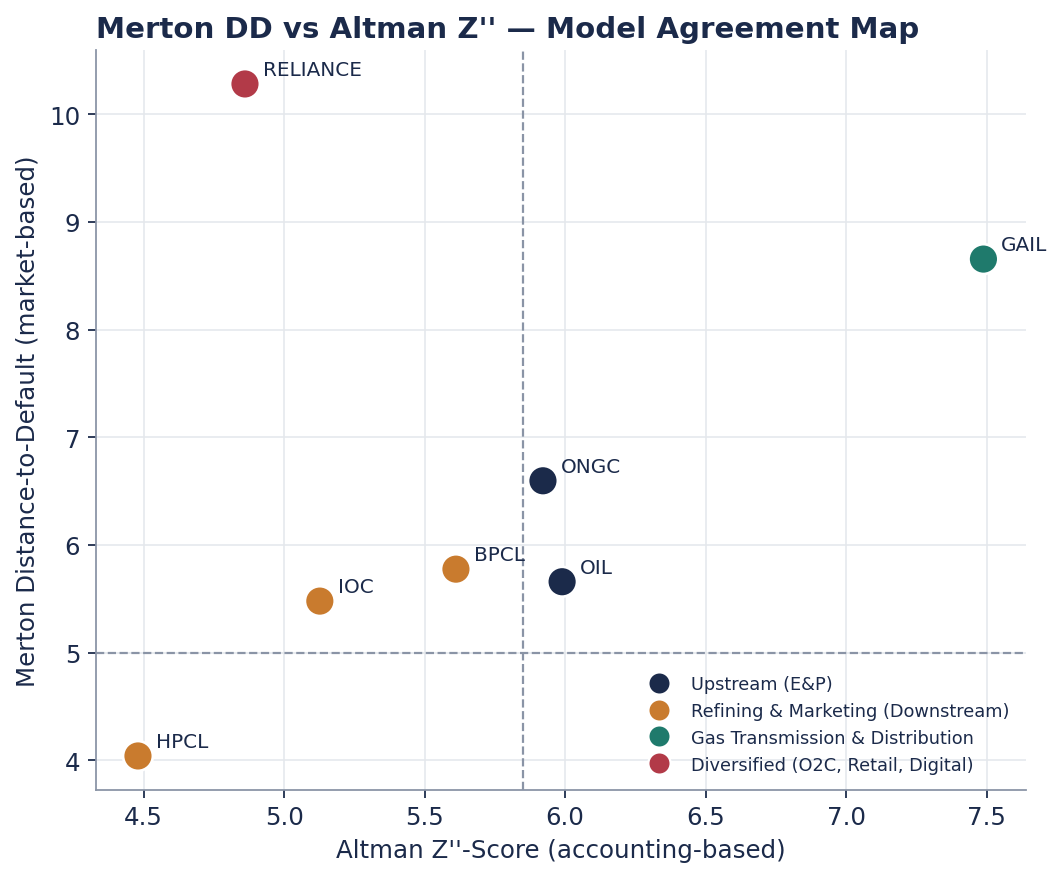

In [27]:
import glob
chart_files = sorted(glob.glob('../outputs/charts/*.png'))
print(f"{len(chart_files)} charts generated in outputs/charts/:")
for f in chart_files:
    print(' -', os.path.basename(f))
display(Image(filename='../outputs/charts/04_dd_vs_altman_scatter.png'))

## Interactive Dashboard

`dashboard/app.py` (Streamlit + Plotly) provides a company selector, business-model filter, credit KPIs, five-year trend charts, model comparison, interactive stress-test sliders, early warnings, and an analyst-interpretation panel. Run with:

```bash
streamlit run dashboard/app.py
```

## Reliance Comparability Analysis

Reliance Industries is a **diversified conglomerate** (Oil-to-Chemicals, Retail, Digital Services/Jio), not a pure-play oil & gas company. Its FY2025 Altman Z'' (4.86, Grey Zone, on a *deteriorating* 5-year trend from 6.16 in FY2021) sits below several of the pure-energy peers despite its enormous Merton DD (10.28, by far the highest in the peer set, driven by its very large market capitalisation relative to debt and its lowest observed equity volatility, 20.8%, in the group). This is a textbook illustration of why the project keeps Reliance in a separate "Diversified Benchmark" peer group rather than blending it into the "Pure Energy" ranking: its market-based Merton profile is dominated by scale and diversification benefits unrelated to oil & gas fundamentals specifically, while its accounting profile (declining ROE, rising Other Liabilities from retail/telecom build-out) tells a different, less flattering story. Any comparison involving Reliance in this project is annotated with this caveat.

In [28]:
reliance_row = comparison[comparison['company']=='RELIANCE']
reliance_altman_trend = five_year_trend(altman)
display(reliance_row)
display(reliance_altman_trend[reliance_altman_trend['company']=='RELIANCE'])

,company,name,business_model,peer_group,merton_dd,merton_pd,altman_z_em,altman_zone,debt_to_ebitda,interest_coverage_ebit,current_ratio_proxy,fcf_to_debt,merton_tier,altman_tier,overall_signal
6,RELIANCE,Reliance Industries Ltd.,"Diversified (O2C, Retail, Digital)",Diversified Benchmark,10.281,0.000,4.861,Grey Zone,2.260,4.634,0.609,0.110,Low Risk,Moderate Risk,Disagreement (Merton: Low Risk / Altman: Moder...


fy,company,2021,2022,2023,2024,2025,change_fy21_fy25,slope_per_year,trend_classification
6,RELIANCE,6.162,6.002,5.607,5.257,4.861,-1.302,-0.335,Deteriorating


## Indian Oil Corporation (IOC) — Deep-Dive Case Study

IOC is used as the primary single-company case study (the project author's prior business-development/ESG background at IOCL is disclosed here for transparency; **the model itself is applied identically to all 7 companies and is not tuned toward any conclusion about IOC** - its Red early-warning flag and rank-6-of-7 credit score below are a direct, unbiased output of the same pipeline run on every peer).

IOC current position:


,company,name,business_model,peer_group,merton_dd,merton_pd,altman_z_em,altman_zone,debt_to_ebitda,interest_coverage_ebit,current_ratio_proxy,fcf_to_debt,merton_tier,altman_tier,overall_signal
1,IOC,Indian Oil Corporation Ltd.,Refining & Marketing (Downstream),Pure Energy,5.478,0.000,5.127,Grey Zone,4.225,2.069,0.955,0.001,Low Risk,Moderate Risk,Disagreement (Merton: Low Risk / Altman: Moder...


IOC 5-year ratio trend:


,fy,debt_to_ebitda,interest_coverage_ebit,roe_pct,fcf_to_debt
5,2021,2.921,9.883,19.459,0.239
6,2022,2.832,7.968,19.266,0.012
7,2023,4.855,2.307,8.377,-0.017
8,2024,1.753,7.586,23.532,0.260
9,2025,4.225,2.069,7.394,0.001


IOC 5-year Altman trend:


,fy,altman_z_em,altman_zone
5,2021,5.046,Grey Zone
6,2022,5.386,Grey Zone
7,2023,5.009,Grey Zone
8,2024,5.783,Grey Zone
9,2025,5.127,Grey Zone


IOC early warning:


,warning_level,triggered_metrics
5,Red,debt_to_ebitda = 4.23 (threshold > 3.5); inter...


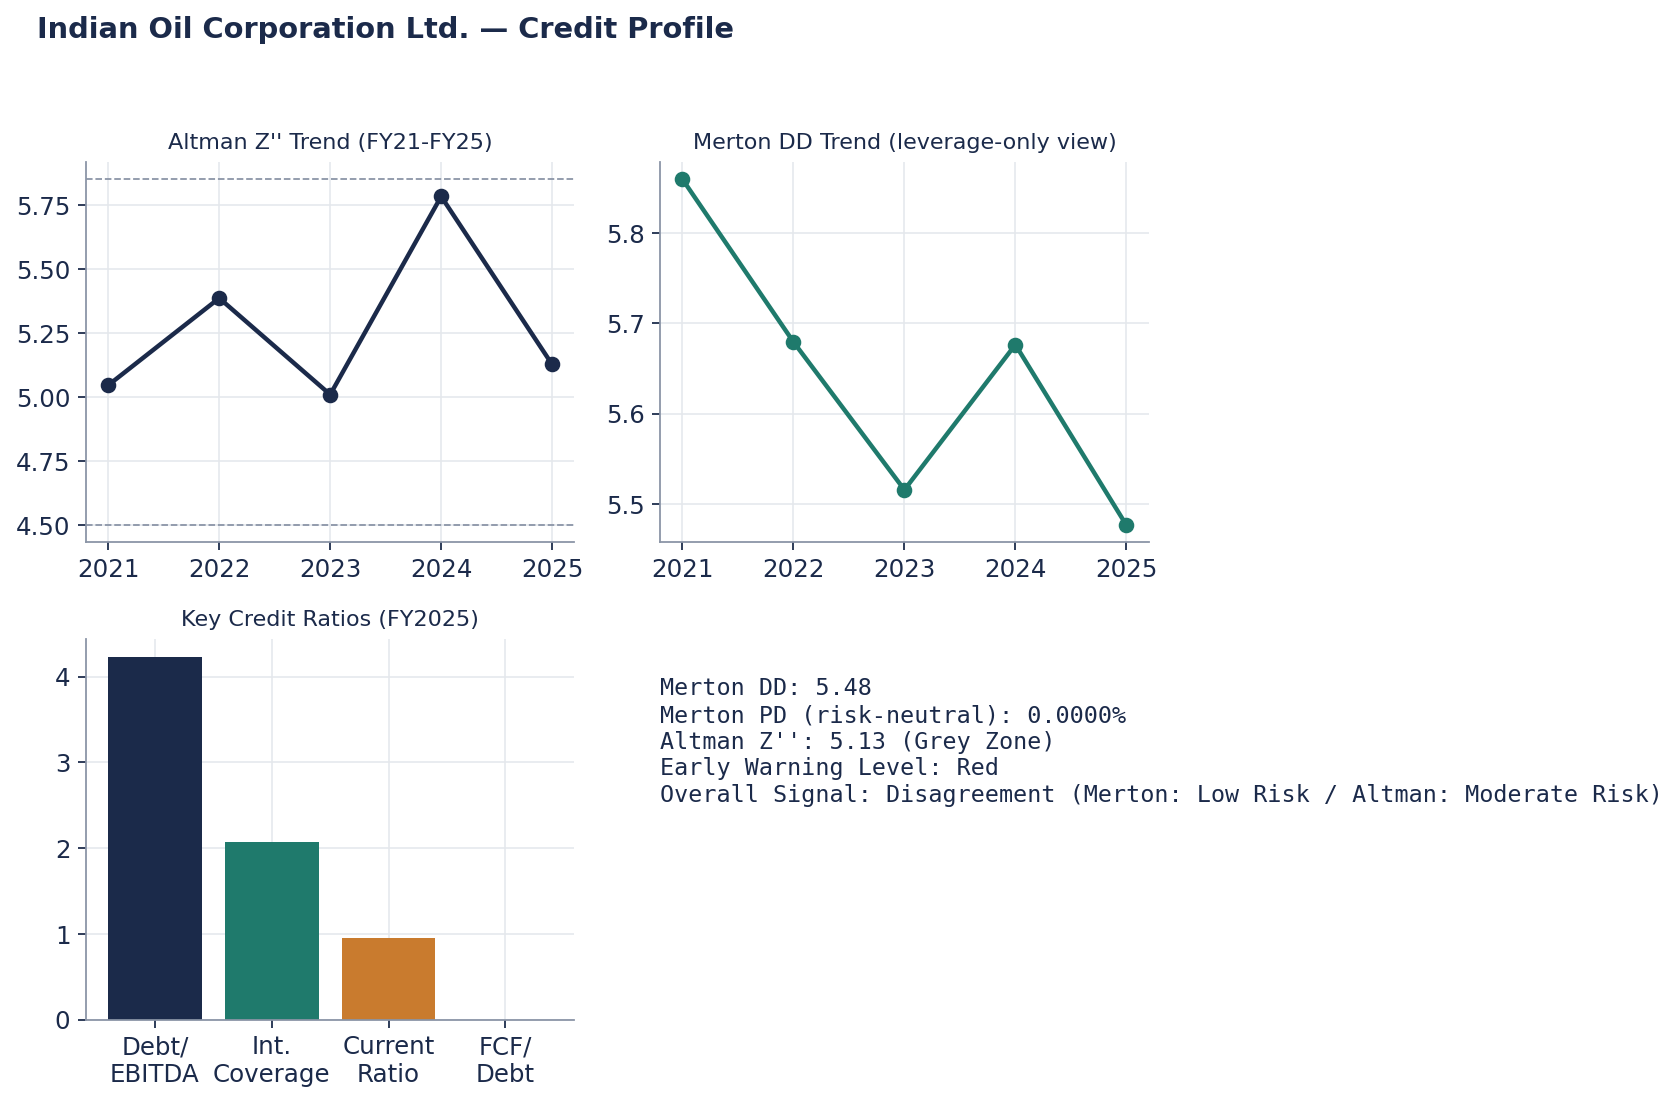

In [29]:
ioc_row = comparison[comparison['company']=='IOC']
ioc_ratios_trend = ratios[ratios['company']=='IOC'][['fy','debt_to_ebitda','interest_coverage_ebit','roe_pct','fcf_to_debt']]
ioc_altman_trend = altman[altman['company']=='IOC'][['fy','altman_z_em','altman_zone']]
ioc_ew = ew[ew['company']=='IOC']
print('IOC current position:'); display(ioc_row)
print('IOC 5-year ratio trend:'); display(ioc_ratios_trend)
print('IOC 5-year Altman trend:'); display(ioc_altman_trend)
print('IOC early warning:'); display(ioc_ew[['warning_level','triggered_metrics']])
display(Image(filename='../outputs/charts/13_company_profile_IOC.png'))

## Final Results Summary

See `outputs/reports/final_report.md` for the complete narrative writeup. Headline results table below.

In [30]:
final_summary = pd.read_csv('../outputs/tables/final_summary.csv')
final_summary[['company','merton_dd','merton_pd','altman_z_em','altman_zone','energy_credit_score','rank','warning_level','overall_signal']]

,company,merton_dd,merton_pd,altman_z_em,altman_zone,energy_credit_score,rank,warning_level,overall_signal
0,RELIANCE,10.281,0.000,4.861,Grey Zone,65.600,2,Yellow,Disagreement (Merton: Low Risk / Altman: Moder...
1,GAIL,8.655,0.000,7.489,Safe Zone,84.400,1,Yellow,Agreement - Low Risk
2,ONGC,6.596,0.000,5.921,Safe Zone,62.700,3,Yellow,Agreement - Low Risk
3,BPCL,5.775,0.000,5.611,Grey Zone,58.300,4,Green,Disagreement (Merton: Low Risk / Altman: Moder...
4,OIL,5.658,0.000,5.989,Safe Zone,57.300,5,Orange,Agreement - Low Risk
5,IOC,5.478,0.000,5.127,Grey Zone,49.000,6,Red,Disagreement (Merton: Low Risk / Altman: Moder...
6,HPCL,4.040,0.000,4.480,Distress Zone,43.500,7,Orange,Disagreement (Merton: Moderate Risk / Altman: ...


In [31]:
import os
os.makedirs('../outputs/tables', exist_ok=True)
comparison.to_csv('../outputs/tables/model_comparison.csv', index=False)
scored.to_csv('../outputs/tables/credit_scores.csv', index=False)
ew.to_csv('../outputs/tables/early_warnings.csv', index=False)
bear.to_csv('../outputs/tables/combined_bear_case.csv', index=False)
rst.to_csv('../outputs/tables/reverse_stress_test.csv', index=False)
print('All result tables exported to outputs/tables/')

All result tables exported to outputs/tables/


## Final Project Audit

See the full audit in `outputs/reports/final_report.md` ("Final Project Audit" section) and the delivery message accompanying this repository. In summary: all 7 companies analysed across FY2021-FY2025 with real, sourced data; both models implemented and validated (7/7 Merton solves converge, 28/28 behavioural sanity checks pass); full stress-testing suite (profitability/debt/equity/combined bear/reverse) implemented and run; early-warning system implemented; 20 charts generated; dashboard built; IOC deep dive completed; all data gaps and modeling simplifications documented in `docs/limitations.md` rather than silently patched; no fabricated data at any point.